In [2]:
!pip install wfdb

In [ ]:
!pip install pytorch-fid

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 106.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 80.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 48.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 33.5 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitli

In [3]:
# Importación de las funciones necesarias

import torch
import torch.optim as optim
import os
import matplotlib.pyplot as plt
import datetime
import sys
import wfdb

In [4]:
# Nos montamos a Google Drive para poder cargar los archivos con las funciones necesarias

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
# Añadimos la ruta en la que se enceuntran estos archivos para poder acceder a ellos

sys.path.append('/content/drive/MyDrive/programacion_ECG')

In [6]:
from funcionescargadatos import *
from funcionespreprocesamientodatos import *
from funcionesclasificacionsenales import *
from funcionescreacionredgan import *
from funcionesdatosgan import *
from funcionesentrenamientogan import *

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
#Intentamos utilizar la GPU si esto es posible porque es más rápida


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

Usando dispositivo: cpu


In [8]:
#Preparación de los datos

diccionario_etiquetas = {"segmentos_N_GAN": 0, "segmentos_A_GAN": 1, "segmentos_O_GAN": 2, "segmentos_noise_GAN": 3}

ruta_drive = "/content/drive/MyDrive/dataset_ECG/challenge2017/entrenamiento_GAN"

segm, etiq = creacion_dataset_GAN (ruta_drive, diccionario_etiquetas)

In [9]:
#1. Inicialización del Dataset de ECG
ecg_dataset = ECGDataset(segm, etiq)

#2. Impresión de su longitud
print(ecg_dataset.__len__())

#3. Obtención de los datos y la señal de uno de los elementos
datos_registro, etiqueta_registro = ecg_dataset.__getitem__(264789)

print(datos_registro)
print(etiqueta_registro)

266096
tensor([[ 0.1014, -0.0273, -0.2092, -0.4074, -0.5779, -0.6817, -0.6985, -0.6321,
         -0.5072, -0.3571, -0.2085, -0.0708,  0.0639,  0.2101,  0.3707,  0.5230,
          0.6191,  0.6073,  0.4670,  0.2361,  0.0109, -0.0918,  0.0058,  0.2927,
          0.6601,  0.9439,  1.0000,  0.7722,  0.3190, -0.2143, -0.6604, -0.8971,
         -0.8893, -0.6876, -0.3944, -0.1156,  0.0770,  0.1585,  0.1414,  0.0539,
         -0.0764, -0.2268, -0.3756, -0.4993, -0.5768, -0.5985, -0.5714, -0.5145,
         -0.4479, -0.3838, -0.3261, -0.2769, -0.2431, -0.2358, -0.2627, -0.3177,
         -0.3775, -0.4088, -0.3832, -0.2908, -0.1433,  0.0306,  0.1951,  0.3171,
          0.3732,  0.3525,  0.2569,  0.1007, -0.0906, -0.2830, -0.4418, -0.5414,
         -0.5736, -0.5497, -0.4943, -0.4348, -0.3907, -0.3690, -0.3686, -0.3882,
         -0.4305, -0.4964, -0.5752, -0.6417, -0.6662, -0.6320, -0.5489, -0.4506,
         -0.3771, -0.3536, -0.3781, -0.4249, -0.4624, -0.4709, -0.4509, -0.4164,
         -0.3822, -0.

In [10]:
dataloader_GAN = creacion_dataloader (segm, etiq)

In [11]:
# Inicializamos las variables que vamos a utilizar

dimension_ruido = 100
batch_size = 16
canales = 1
features_generador = 64
clases = 4
longitud=257
embed = 64


In [12]:
# Iniciación del Generador y del Discriminador

generador =  Generador_CWGAN_GP_1D (dimension_ruido, canales, features_generador, clases, longitud, embed).to(device)

discriminador = Discriminador_CWGAN_GP_1D (canales, features_generador, clases, longitud).to(device)

In [13]:
input_noise = torch.randn(batch_size, dimension_ruido, 1).to(device)
etiquetas = torch.randint(0, clases, (batch_size,)).to(device)

output = generador(input_noise, etiquetas)
print(output.shape)  # debería ser (16, 1, 256)

torch.Size([16, 1, 257])


In [14]:
input_tensor = torch.randn(batch_size, canales, longitud).to(device)
labels = torch.randint(0, clases, (batch_size,)).to(device)

output = discriminador(input_tensor, labels)
print(output.shape)

torch.Size([16, 1])


In [15]:
# Una vez creados el generador y el discriminador es necesario inicializar los pesos de estos


generador.apply(inicializacion_pesos)
discriminador.apply(inicializacion_pesos)

Discriminador_CWGAN_GP_1D(
  (embedding): Embedding(4, 257)
  (discriminador): Sequential(
    (0): Conv1d(2, 64, kernel_size=(4,), stride=(2,), padding=(1,))
    (1): LeakyReLU(negative_slope=0.2)
    (2): Sequential(
      (0): Conv1d(64, 128, kernel_size=(4,), stride=(2,), padding=(1,), bias=False)
      (1): InstanceNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=False)
      (2): LeakyReLU(negative_slope=0.2)
    )
    (3): Sequential(
      (0): Conv1d(128, 256, kernel_size=(4,), stride=(2,), padding=(1,), bias=False)
      (1): InstanceNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=False)
      (2): LeakyReLU(negative_slope=0.2)
    )
    (4): Sequential(
      (0): Conv1d(256, 512, kernel_size=(4,), stride=(2,), padding=(1,), bias=False)
      (1): InstanceNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=False)
      (2): LeakyReLU(negative_slope=0.2)
    )
    (5): Conv1d(512, 1, kernel_size=(4,), stride=(2,))
 

In [16]:
# Definición de los optimizadores

optim_generador, optim_discriminador = creacion_optimizadores(generador, discriminador)

In [ ]:
# Antes del entrenamiento es recomendable cerrar las figuras abiertas:

plt.close('all')

start_time = datetime.datetime.now()

entrenar_cwgan_gp_prueba2(generador, discriminador, dataloader_GAN, optim_generador, optim_discriminador, device, epochs=50, dim_noise=100, lambda_gp=10, critic_iter=4, verbose = True)



end_time = datetime.datetime.now()
total_training_time = end_time - start_time
print(f"\nEntrenamiento completado en: {total_training_time}")


start_time = datetime.datetime.now()



En este momento comienza el entrenamiento de la red GAN (desde la época 0):


/usr/local/lib/python3.11/dist-packages/torch/autograd/graph.py:823: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:180.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Época [1/50] - Batch [1/4158] - Pérdida D: 7.2398 - Pérdida G: 0.0709
Época [1/50] - Batch [101/4158] - Pérdida D: -4.7056 - Pérdida G: 3.8755
Época [1/50] - Batch [201/4158] - Pérdida D: -2.3655 - Pérdida G: 3.8144
Época [1/50] - Batch [301/4158] - Pérdida D: -0.7912 - Pérdida G: 4.9826
Época [1/50] - Batch [401/4158] - Pérdida D: -0.6983 - Pérdida G: 4.8914
Época [1/50] - Batch [501/4158] - Pérdida D: -0.4119 - Pérdida G: 5.4746
Época [1/50] - Batch [601/4158] - Pérdida D: -0.7338 - Pérdida G: 4.6866
Época [1/50] - Batch [701/4158] - Pérdida D: -0.7174 - Pérdida G: 4.3802
Época [1/50] - Batch [801/4158] - Pérdida D: -0.2327 - Pérdida G: 3.3308
Época [1/50] - Batch [901/4158] - Pérdida D: -0.7434 - Pérdida G: 4.5674
Época [1/50] - Batch [1001/4158] - Pérdida D: -0.3298 - Pérdida G: 4.2743
Época [1/50] - Batch [1101/4158] - Pérdida D: -0.7250 - Pérdida G: 5.1953
Época [1/50] - Batch [1201/4158] - Pérdida D: -0.5914 - Pérdida G: 5.5028
Época [1/50] - Batch [1301/4158] - Pérdida D: -0.21

In [ ]:
%cd /content/

/content


Generador entrenado cargado exitosamente.
Generando 16 señales para las clases: [0 1 2 3 0 1 2 3 0 1 2 3 0 1 2 3]
Señales generadas. Forma final para visualización: (16, 257)


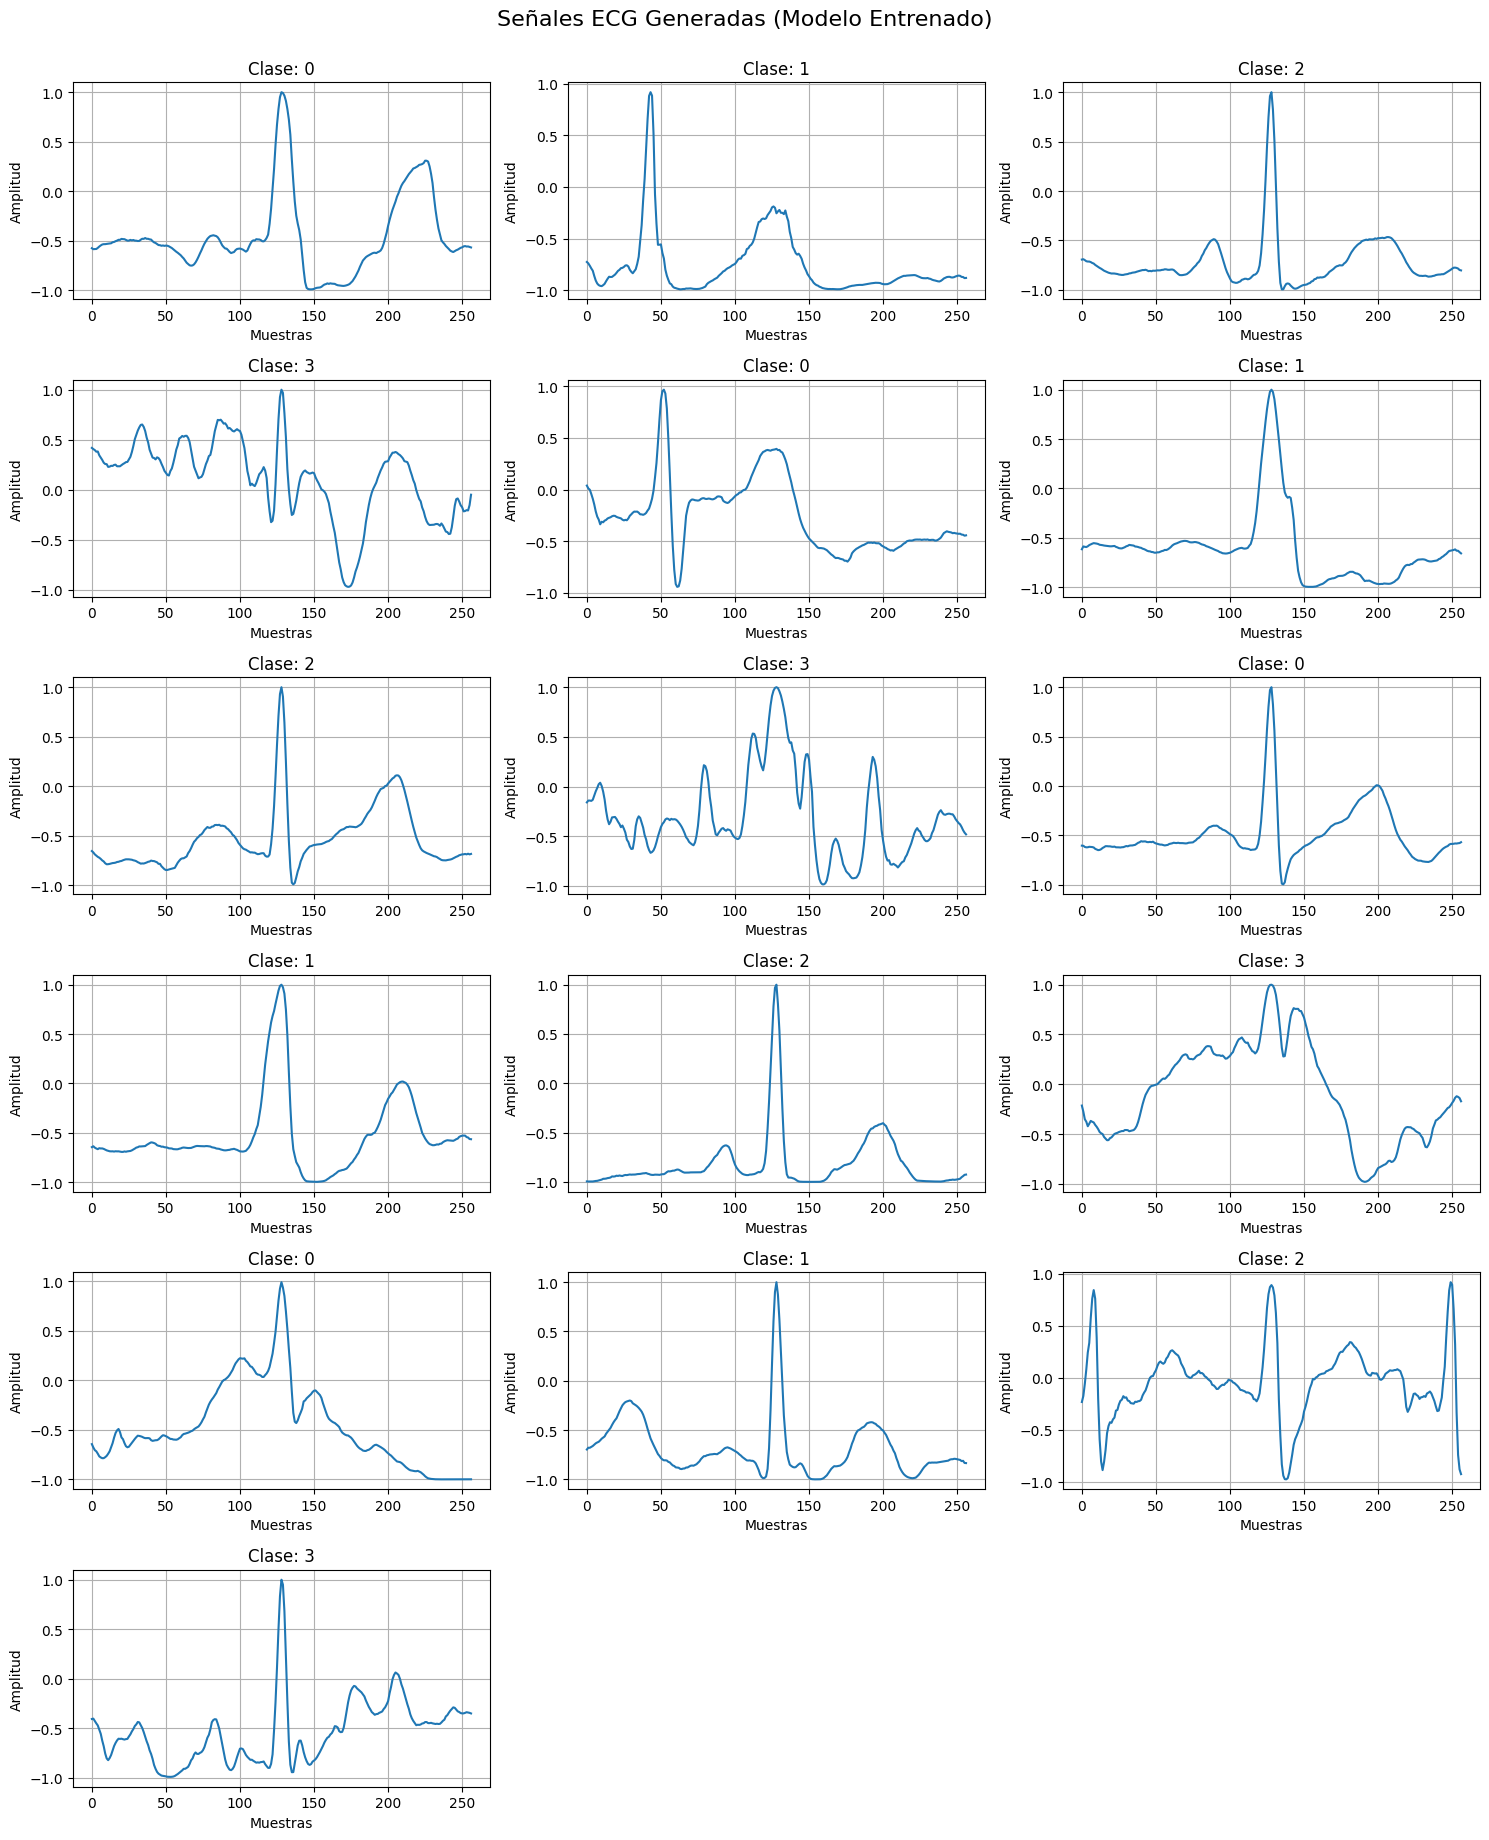


¡Proceso de generación y visualización completado!
Ahora puedes inspeccionar visualmente la calidad de las señales.


In [17]:
ruta_al_generador_final = "/content/drive/MyDrive/ultima_prueba/generador_final_20250706_150909.pth"
# Si el timestamp es diferente, ¡AJÚSTALO!

# --- 6. Carga los parámetros (pesos) en la arquitectura del modelo ---
try:
    generador.load_state_dict(torch.load(ruta_al_generador_final, map_location=device))
    generador.eval() # IMPORTANTE: Pon el modelo en modo de evaluación para inferencia
    print("Generador entrenado cargado exitosamente.")
except FileNotFoundError:
    print(f"ERROR: No se encontró el archivo de modelo en {ruta_al_generador_final}")
    print("Por favor, verifica que la ruta sea correcta y que el archivo exista en tu Drive.")
    print("Si estás en una nueva sesión de Colab, asegúrate de haber montado Google Drive.")
    exit()

# --- 7. Generar nuevas señales de prueba ---
num_señales_a_generar = 16 # Puedes seguir generando 12 señales si quieres, o cambiar a 16.
                           # Lo importante es que el número de ruido y etiquetas coincida con esto.

# Define las etiquetas de las clases que quieres generar.
labels_para_generar = torch.tensor(
    [i % clases for i in range(num_señales_a_generar)], # Usar NUM_CLASSES
    dtype=torch.long
).to(device)

print(f"Generando {num_señales_a_generar} señales para las clases: {labels_para_generar.cpu().numpy()}")

# Genera ruido aleatorio para las nuevas señales
noise = torch.randn((num_señales_a_generar, dimension_ruido, 1), device=device)

# Desactiva el cálculo de gradientes para la inferencia
with torch.no_grad():
    señales_generadas = generador(input_noise, labels_para_generar)

# Las señales generadas suelen tener la forma (BATCH_SIZE, CHANNELS_IMG, SIGNAL_LENGTH)
señales_generadas_np = señales_generadas.squeeze(1).cpu().numpy()

print(f"Señales generadas. Forma final para visualización: {señales_generadas_np.shape}")

# --- 8. Visualizar las señales generadas ---
num_cols = 3
num_rows = (num_señales_a_generar + num_cols - 1) // num_cols
fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 5, num_rows * 3))
axes = axes.flatten()

for i in range(num_señales_a_generar):
    ax = axes[i]
    ax.plot(señales_generadas_np[i])
    ax.set_title(f"Clase: {labels_para_generar[i].item()}")
    ax.grid(True)
    ax.set_xlabel("Muestras")
    ax.set_ylabel("Amplitud")

for i in range(num_señales_a_generar, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.suptitle("Señales ECG Generadas (Modelo Entrenado)", y=1.02, fontsize=16)
plt.show()

print("\n¡Proceso de generación y visualización completado!")
print("Ahora puedes inspeccionar visualmente la calidad de las señales.")



